In [71]:
import os

CONFIG_FILE = "generate_dataset3.yml"
OUTPUT_DIR = os.path.join("..", "data")
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_WITH_TIMESTAMP = True
SAVE_PREFIX = "dataset3" # groundtruth_1360_1800

print(f"Config file: {CONFIG_FILE}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Timestamped filenames: {SAVE_WITH_TIMESTAMP}")


Config file: generate_dataset3.yml
Output directory: ../data
Timestamped filenames: True


### 1. Import

In [72]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Sequence, Tuple
import os
import yaml

import numpy as np
from scipy import integrate
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
# Load configuration file
with open("generate_dataset3.yml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# --- wavenumber grid ---
WAVENUM_MIN = config["wavenumber"]["min"]
WAVENUM_MAX = config["wavenumber"]["max"]
STEP        = config["wavenumber"]["step"]

# --- envelope parameters ---
SUBPEAKS_RANGE      = tuple(config["envelope"]["subpeaks_range"])
AMP_RANGE           = tuple(config["envelope"]["amplitude_range"])
LORENTZ_FWHM_RANGE  = tuple(config["envelope"]["lorentz_fwhm_range"])

component_amp_cfg = config.get("component_amplitude")
if component_amp_cfg is not None:
    COMPONENT_AMP = {
        "alpha": tuple(component_amp_cfg.get("alpha_helix", AMP_RANGE)),
        "beta_sheet": tuple(component_amp_cfg.get("beta_sheet", AMP_RANGE)),
        "beta_turn": tuple(component_amp_cfg.get("beta_turn", AMP_RANGE)),
        "other": tuple(component_amp_cfg.get("other", AMP_RANGE)),
    }
else:
    COMPONENT_AMP = None

# --- peak count control ---
TOTAL_PEAKS_RANGE       = tuple(config["peak_control"]["total_peaks_range"])
ALPHA_HELIX_PEAKS_RANGE = tuple(config["peak_control"]["component_peaks"]["alpha_helix"])
BETA_SHEET_PEAKS_RANGE  = tuple(config["peak_control"]["component_peaks"]["beta_sheet"])
BETA_TURN_PEAKS_RANGE   = tuple(config["peak_control"]["component_peaks"]["beta_turn"])
OTHER_PEAKS_RANGE       = tuple(config["peak_control"]["component_peaks"]["other"])

CHECK_OVERLAP = config["peak_control"]["validation"]["check_overlap"]
MIN_SEPARATION = config["peak_control"]["validation"]["min_separation"]
ENFORCE_TOTAL  = config["peak_control"]["validation"]["enforce_total"]

COMPONENT_AMP = {
    "alpha": tuple(config["component_amplitude"]["alpha_helix"]),
    "beta_sheet": tuple(config["component_amplitude"]["beta_sheet"]),
    "beta_turn": tuple(config["component_amplitude"]["beta_turn"]),
    "other": tuple(config["component_amplitude"]["other"]),
}

# --- broadening ---
GAUSS_FWHM_RANGE   = tuple(config["broadening"]["gauss_fwhm_range"])
DOPPLER_FWHM_RANGE = tuple(config["broadening"]["doppler_fwhm_range"])

# --- noise ---
NOISE_STD_REL          = config["noise"]["detector_noise_std"]
MICRO_PERTURBATION_STD = config["noise"]["micro_perturbation_std"]

# --- baseline drift ---
BASELINE_DRIFT_AMP   = config["baseline_drift"]["amplitude"]
BASELINE_DRIFT_PERIOD = config["baseline_drift"]["period"]
RANDOM_DRIFT_STD      = config["baseline_drift"]["random_drift_std"]

# --- postprocess settings ---
POSTPROCESS_CFG = config.get("postprocess", {})
TARGET_MAX_AMPLITUDE = POSTPROCESS_CFG.get("target_max_amplitude")

# --- peak definitions ---
ALPHA_HELIX_PEAK = (
    config["peaks"]["alpha_helix"]["center"],
    config["peaks"]["alpha_helix"]["tolerance"],
)
BETA_SHEET_PEAKS = [tuple(peak) for peak in config["peaks"]["beta_sheet"]]
BETA_TURN_PEAKS  = [tuple(peak) for peak in config["peaks"]["beta_turn"]]
OTHER_PEAKS_REGIONS = [tuple(region) for region in config["peaks"]["other_peaks"]["regions"]]
_raw_region_weights = np.asarray(
    config["peaks"]["other_peaks"].get("region_weights", [1.0] * len(OTHER_PEAKS_REGIONS)),
    dtype=np.float32,
)
if np.all(_raw_region_weights <= 0):
    OTHER_PEAKS_REGION_WEIGHTS = np.full(len(OTHER_PEAKS_REGIONS), 1.0 / len(OTHER_PEAKS_REGIONS), dtype=np.float32)
else:
    OTHER_PEAKS_REGION_WEIGHTS = _raw_region_weights / _raw_region_weights.sum()
OTHER_PEAKS_FWHM_RANGE = tuple(config["peaks"]["other_peaks"]["fwhm_range"])
OTHER_PEAKS_AMP_RATIO  = tuple(config["peaks"]["other_peaks"]["amplitude_ratio"])

# --- dataset settings ---
N_SAMPLES                = config["dataset"]["n_samples"]
OUTPUT_FILENAME          = config["dataset"]["output_filename"]
RANDOM_SEED              = config["dataset"]["random_seed"]
PEAK_ALLOCATION_STRATEGY = config["dataset"]["peak_allocation_strategy"]
ALLOW_PEAK_ADJUSTMENT    = config["dataset"]["allow_peak_adjustment"]

# --- visualization ---
FIGURE_SIZE = tuple(config["visualization"]["figure_size"])
DPI         = config["visualization"]["dpi"]

# plotting style
plt.style.use(config["visualization"]["style"])
sns.set_palette(config["visualization"]["palette"])

print("Configuration file loaded successfully!")
print(f"Wavenumber range: {WAVENUM_MIN} - {WAVENUM_MAX} cm⁻¹")
print(f"Wavenumber step: {STEP} cm⁻¹")
print(f"Total peaks range: {TOTAL_PEAKS_RANGE[0]}-{TOTAL_PEAKS_RANGE[1]} peaks")
print(f"beta_turn peaks range: {BETA_TURN_PEAKS_RANGE[0]}-{BETA_TURN_PEAKS_RANGE[1]}")
print(f"Other peaks range: {OTHER_PEAKS_RANGE[0]}-{OTHER_PEAKS_RANGE[1]}")
print(f"Noise level: {NOISE_STD_REL * 100:.1f}%")
print(f"Number of samples: {N_SAMPLES}")
print(f"Peak allocation strategy: {PEAK_ALLOCATION_STRATEGY}")

Configuration file loaded successfully!
Wavenumber range: 1360.0 - 1800.0 cm⁻¹
Wavenumber step: 1.0 cm⁻¹
Total peaks range: 15-24 peaks
beta_turn peaks range: 0-0
Other peaks range: 12-18
Noise level: 0.4%
Number of samples: 10000
Peak allocation strategy: balanced


In [74]:
from dataclasses import dataclass

@dataclass
class DatasetSample:
    """Synthetic spectrum components for ground-truth dataset."""
    alpha_helix: np.ndarray
    beta_sheet: np.ndarray
    beta_turn: np.ndarray
    other_peaks: np.ndarray
    composite: np.ndarray


def _sample_int_range(rng: np.random.Generator, bounds: Sequence[int]) -> int:
    """Sample an integer with an inclusive upper bound."""
    low, high = map(int, bounds)
    if low > high:
        raise ValueError(f"Invalid integer range: {bounds}")
    if low == high:
        return low
    return int(rng.integers(low, high + 1))


def generate_sample(x_axis: np.ndarray, rng: np.random.Generator) -> DatasetSample:
    """Generate one sample following the configured alpha / beta / turn / other layout."""
    alpha_peaks = _sample_int_range(rng, ALPHA_HELIX_PEAKS_RANGE)
    beta_sheet_peaks = _sample_int_range(rng, BETA_SHEET_PEAKS_RANGE)
    beta_turn_peaks = _sample_int_range(rng, BETA_TURN_PEAKS_RANGE)
    other_peaks = _sample_int_range(rng, OTHER_PEAKS_RANGE)

    total_peaks = alpha_peaks + beta_sheet_peaks + beta_turn_peaks + other_peaks
    print(f"Peak allocation: α={alpha_peaks}, β_sheet={beta_sheet_peaks}, β_turn={beta_turn_peaks}, other={other_peaks}")
    print(f"Total peaks: {total_peaks}")

    alpha_amp_range = COMPONENT_AMP["alpha"] if COMPONENT_AMP else AMP_RANGE
    beta_sheet_amp_range = COMPONENT_AMP["beta_sheet"] if COMPONENT_AMP else AMP_RANGE
    beta_turn_amp_range = COMPONENT_AMP["beta_turn"] if COMPONENT_AMP else AMP_RANGE
    other_amp_range = COMPONENT_AMP["other"] if COMPONENT_AMP else AMP_RANGE

    alpha = np.zeros_like(x_axis)
    for _ in range(alpha_peaks):
        centre = ALPHA_HELIX_PEAK[0] + rng.uniform(-ALPHA_HELIX_PEAK[1], ALPHA_HELIX_PEAK[1])
        fwhm = rng.uniform(*LORENTZ_FWHM_RANGE)
        amp = rng.uniform(*alpha_amp_range)
        peak = _lorentzian(x_axis, centre, fwhm, amp)
        g_fwhm = rng.uniform(*GAUSS_FWHM_RANGE)
        d_fwhm = rng.uniform(*DOPPLER_FWHM_RANGE)
        alpha += _blur(peak, g_fwhm * FWHM_TO_SIGMA, d_fwhm * FWHM_TO_SIGMA)

    beta_sheet = np.zeros_like(x_axis)
    for _ in range(beta_sheet_peaks):
        center, tolerance = rng.choice(BETA_SHEET_PEAKS)
        centre = center + rng.uniform(-tolerance, tolerance)
        fwhm = rng.uniform(*LORENTZ_FWHM_RANGE)
        amp = rng.uniform(*beta_sheet_amp_range)
        peak = _lorentzian(x_axis, centre, fwhm, amp)
        g_fwhm = rng.uniform(*GAUSS_FWHM_RANGE)
        d_fwhm = rng.uniform(*DOPPLER_FWHM_RANGE)
        beta_sheet += _blur(peak, g_fwhm * FWHM_TO_SIGMA, d_fwhm * FWHM_TO_SIGMA)

    beta_turn = np.zeros_like(x_axis)
    for _ in range(beta_turn_peaks):
        center, tolerance = rng.choice(BETA_TURN_PEAKS)
        centre = center + rng.uniform(-tolerance, tolerance)
        fwhm = rng.uniform(*LORENTZ_FWHM_RANGE)
        amp = rng.uniform(*beta_turn_amp_range)
        peak = _lorentzian(x_axis, centre, fwhm, amp)
        g_fwhm = rng.uniform(*GAUSS_FWHM_RANGE)
        d_fwhm = rng.uniform(*DOPPLER_FWHM_RANGE)
        beta_turn += _blur(peak, g_fwhm * FWHM_TO_SIGMA, d_fwhm * FWHM_TO_SIGMA)

    other = np.zeros_like(x_axis)
    for _ in range(other_peaks):
        region_idx = rng.choice(len(OTHER_PEAKS_REGIONS), p=OTHER_PEAKS_REGION_WEIGHTS)
        region_min, region_max = OTHER_PEAKS_REGIONS[region_idx]
        centre = rng.uniform(region_min, region_max)
        fwhm = rng.uniform(*OTHER_PEAKS_FWHM_RANGE)
        base_amp = rng.uniform(*other_amp_range)
        amp_scale = rng.uniform(*OTHER_PEAKS_AMP_RATIO)
        amp = base_amp * amp_scale
        peak = _lorentzian(x_axis, centre, fwhm, amp)
        g_fwhm = rng.uniform(*GAUSS_FWHM_RANGE)
        d_fwhm = rng.uniform(*DOPPLER_FWHM_RANGE)
        other += _blur(peak, g_fwhm * FWHM_TO_SIGMA, d_fwhm * FWHM_TO_SIGMA)

    composite_clean = alpha + beta_sheet + beta_turn + other
    baseline_drift = _generate_baseline_drift(x_axis, rng, composite_clean.max())
    composite_with_drift = composite_clean + baseline_drift
    composite_noisy = _add_realistic_noise(composite_with_drift, rng, composite_clean.max())

    if TARGET_MAX_AMPLITUDE:
        current_max = float(np.max(composite_noisy))
        if current_max > 0:
            scale = TARGET_MAX_AMPLITUDE / current_max
            alpha *= scale
            beta_sheet *= scale
            beta_turn *= scale
            other *= scale
            composite_clean *= scale
            baseline_drift *= scale
            composite_with_drift *= scale
            composite_noisy *= scale

    return DatasetSample(
        alpha_helix=alpha,
        beta_sheet=beta_sheet,
        beta_turn=beta_turn,
        other_peaks=other,
        composite=composite_noisy
    )

In [75]:
# Initialize wavenumber axis and random number generator
x_axis = np.arange(WAVENUM_MIN, WAVENUM_MAX + STEP, STEP)

if RANDOM_SEED is None or str(RANDOM_SEED).strip().lower() in {"", "none", "null"}:
    generator_rng = np.random.default_rng()
    print("Using random seed")
else:
    try:
        seed_value = int(RANDOM_SEED)
    except (ValueError, TypeError):
        generator_rng = np.random.default_rng()
        print(f"Seed value '{RANDOM_SEED}' is invalid, using random seed")
    else:
        generator_rng = np.random.default_rng(seed_value)
        print(f"Using fixed random seed: {seed_value}")

print(f"Wavenumber axis length: {len(x_axis)}")
print(f"Wavenumber range: {x_axis.min():.1f} - {x_axis.max():.1f} cm⁻¹")


Using fixed random seed: 1234
Wavenumber axis length: 441
Wavenumber range: 1360.0 - 1800.0 cm⁻¹


In [76]:
# Internal utility constants
_ln2 = np.log(2.0)
FWHM_TO_SIGMA = 1.0 / (2.0 * np.sqrt(2.0 * _ln2))

def _lorentzian(x: np.ndarray, x0: float, gamma: float, amp: float) -> np.ndarray:
    """Generate Lorentzian peak."""
    half_gamma = 0.5 * gamma
    return amp * (half_gamma ** 2) / ((x - x0) ** 2 + half_gamma ** 2)

def _gaussian_kernel(sigma: float) -> np.ndarray:
    """Generate Gaussian kernel for broadening."""
    half_pts = int(np.ceil(3 * sigma / STEP))
    grid = np.arange(-half_pts, half_pts + 1) * STEP
    k = np.exp(-0.5 * (grid / sigma) ** 2)
    return k / k.sum()

def _blur(signal: np.ndarray, sigma_instr: float, sigma_dopp: float) -> np.ndarray:
    """Apply Gaussian broadening to signal."""
    sigma_tot = np.sqrt(sigma_instr ** 2 + sigma_dopp ** 2)
    return np.convolve(signal, _gaussian_kernel(sigma_tot), mode="same")


Generate simulated spectra (general function)

In [77]:
def generate_spectrum(x: np.ndarray, peak_config: dict, rng: np.random.Generator) -> np.ndarray:
    """General spectrum generation function"""
    spectrum = np.zeros_like(x)
    
    # Generate peaks
    n_peaks = _sample_int_range(rng, peak_config['count_range'])
    amp_range = peak_config['amplitude_range']
    fwhm_range = peak_config['fwhm_range']
    
    for _ in range(n_peaks):
        # Select peak position
        if 'regions' in peak_config:
            region = rng.choice(peak_config['regions'])
            centre = rng.uniform(region[0], region[1])
        elif 'centers' in peak_config:
            center, tolerance = rng.choice(peak_config['centers'])
            centre = center + rng.uniform(-tolerance, tolerance)
        else:
            centre = peak_config['center'] + rng.uniform(-peak_config['tolerance'], peak_config['tolerance'])
        
        # Generate peak parameters
        fwhm = rng.uniform(*fwhm_range)
        amp = rng.uniform(*amp_range)
        
        spectrum += _lorentzian(x, centre, fwhm, amp)
    
    # Apply broadening
    g_fwhm = rng.uniform(*GAUSS_FWHM_RANGE)
    d_fwhm = rng.uniform(*DOPPLER_FWHM_RANGE)
    return _blur(spectrum, g_fwhm * FWHM_TO_SIGMA, d_fwhm * FWHM_TO_SIGMA)

Noise and baseline drift

In [78]:
def _generate_baseline_drift(x: np.ndarray, rng: np.random.Generator, max_amp: float) -> np.ndarray:
    """Generate realistic baseline drift."""
    # Generate multiple frequency components for realistic drift
    drift = np.zeros_like(x)
    
    # Low frequency drift (slow baseline changes)
    freq1 = 2 * np.pi / BASELINE_DRIFT_PERIOD
    phase1 = rng.uniform(0, 2 * np.pi)
    amp1 = rng.uniform(0.5, 1.0) * BASELINE_DRIFT_AMP * max_amp
    drift += amp1 * np.sin(freq1 * x + phase1)
    
    # Medium frequency drift
    freq2 = 2 * np.pi / (BASELINE_DRIFT_PERIOD * 0.5)
    phase2 = rng.uniform(0, 2 * np.pi)
    amp2 = rng.uniform(0.3, 0.7) * BASELINE_DRIFT_AMP * max_amp
    drift += amp2 * np.sin(freq2 * x + phase2)
    
    # Add some random low frequency noise
    random_drift = rng.normal(0, RANDOM_DRIFT_STD * max_amp, size=x.size)
    # Smooth random drift
    random_drift = gaussian_filter1d(random_drift, sigma=5)
    
    return drift + random_drift

def _add_realistic_noise(signal: np.ndarray, rng: np.random.Generator, max_amp: float) -> np.ndarray:
    """Add realistic noise including detector noise and micro-perturbations."""
    # Detector noise (white noise)
    detector_noise = rng.normal(0, NOISE_STD_REL * max_amp, size=signal.size)
    
    # Micro-perturbations at peak positions (simulate sampling errors)
    micro_noise = np.zeros_like(signal)
    for i in range(1, signal.size - 1):
        if signal[i] > signal[i-1] and signal[i] > signal[i+1]:  # Peak position
            # Use absolute value to ensure positive scale parameter
            perturbation_std = MICRO_PERTURBATION_STD * abs(signal[i])
            micro_noise[i] = rng.normal(0, perturbation_std)  # Micro-perturbation at peak
    
    # Combine all noise components
    return signal + detector_noise + micro_noise

Peak allocation: α=2, β_sheet=4, β_turn=0, other=18
Total peaks: 24


/var/folders/_p/nn9gm6dx5l1c43zg9v3kwwch0000gn/T/ipykernel_75641/2853437525.py:46: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/weianqi/Desktop/Photothermal Spectroscopy Deconvolution/spectral segmentation/spectral_segmentation/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


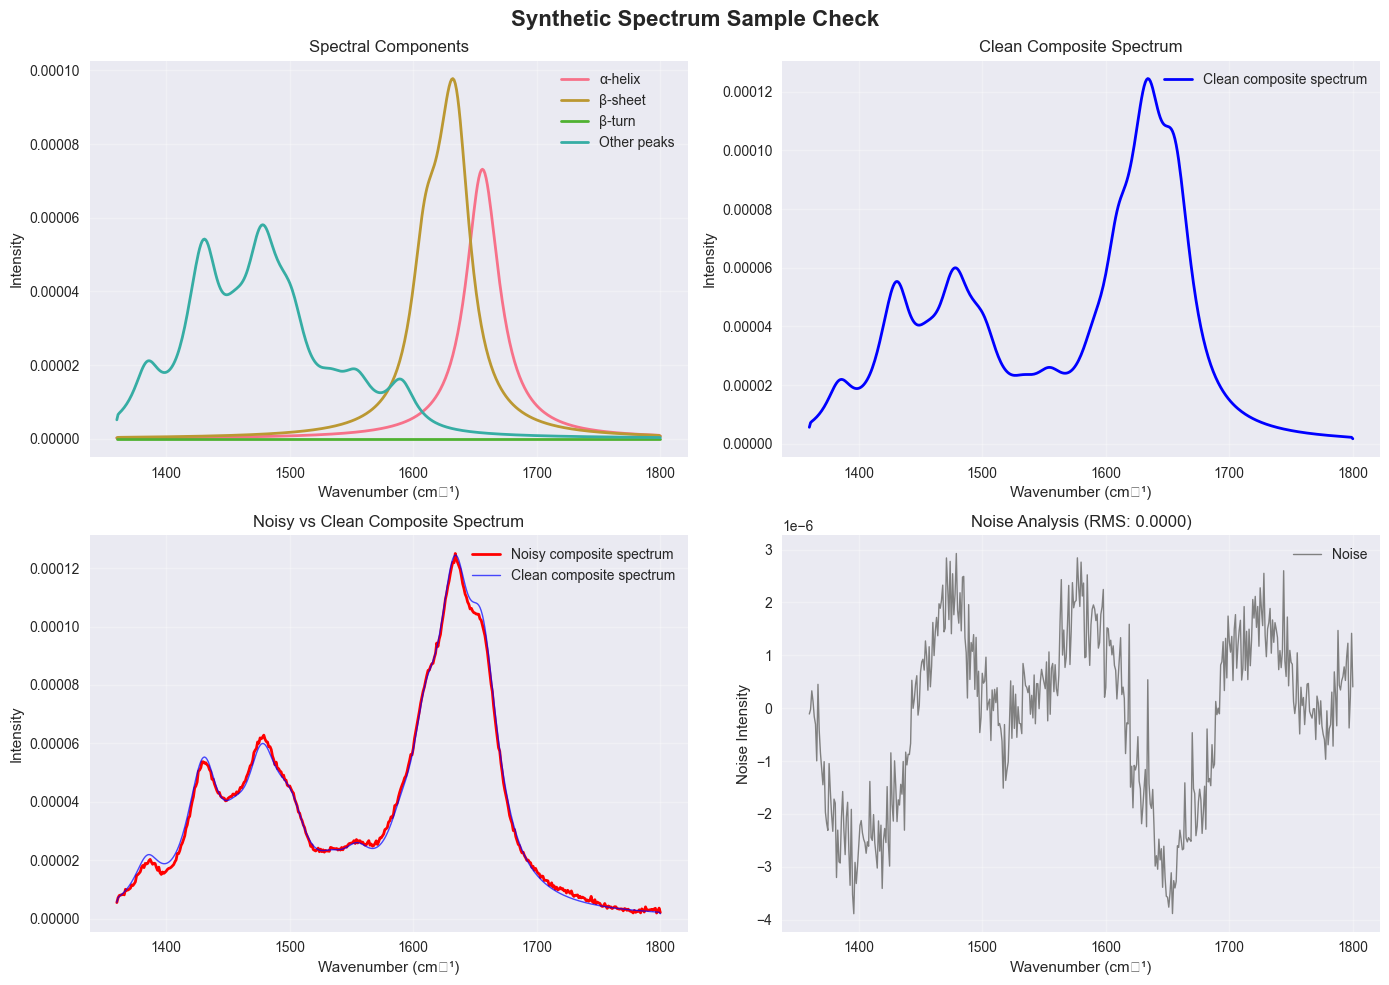

Sample generation completed!
Component intensities: α=0.000, β=0.000, β_turn=0.000
Composite spectrum intensities: clean=0.000, noisy=0.000


In [79]:
# Visualization check - generate single sample
sample = generate_sample(x_axis, generator_rng)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=FIGURE_SIZE, dpi=DPI)
fig.suptitle('Synthetic Spectrum Sample Check', fontsize=16, fontweight='bold')

# Spectral components
axes[0, 0].plot(x_axis, sample.alpha_helix, label='α-helix', linewidth=2)
axes[0, 0].plot(x_axis, sample.beta_sheet, label='β-sheet', linewidth=2)
axes[0, 0].plot(x_axis, sample.beta_turn, label='β-turn', linewidth=2)
axes[0, 0].plot(x_axis, sample.other_peaks, label='Other peaks', linewidth=2)
axes[0, 0].set_xlabel('Wavenumber (cm⁻¹)')
axes[0, 0].set_ylabel('Intensity')
axes[0, 0].set_title('Spectral Components')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Clean composite spectrum
composite_clean = sample.alpha_helix + sample.beta_sheet + sample.beta_turn + sample.other_peaks
axes[0, 1].plot(x_axis, composite_clean, label='Clean composite spectrum', linewidth=2, color='blue')
axes[0, 1].set_xlabel('Wavenumber (cm⁻¹)')
axes[0, 1].set_ylabel('Intensity')
axes[0, 1].set_title('Clean Composite Spectrum')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Noisy composite spectrum
axes[1, 0].plot(x_axis, sample.composite, label='Noisy composite spectrum', linewidth=2, color='red')
axes[1, 0].plot(x_axis, composite_clean, label='Clean composite spectrum', linewidth=1, color='blue', alpha=0.7)
axes[1, 0].set_xlabel('Wavenumber (cm⁻¹)')
axes[1, 0].set_ylabel('Intensity')
axes[1, 0].set_title('Noisy vs Clean Composite Spectrum')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Noise analysis
noise = sample.composite - composite_clean
axes[1, 1].plot(x_axis, noise, label='Noise', linewidth=1, color='gray')
axes[1, 1].set_xlabel('Wavenumber (cm⁻¹)')
axes[1, 1].set_ylabel('Noise Intensity')
axes[1, 1].set_title(f'Noise Analysis (RMS: {np.sqrt(np.mean(noise**2)):.4f})')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Sample generation completed!")
print(f"Component intensities: α={np.max(sample.alpha_helix):.3f}, β={np.max(sample.beta_sheet):.3f}, β_turn={np.max(sample.beta_turn):.3f}")
print(f"Composite spectrum intensities: clean={np.max(composite_clean):.3f}, noisy={np.max(sample.composite):.3f}")

In [80]:
# Generate dataset and save
from datetime import datetime

print(f"Generating {N_SAMPLES} samples...")

alpha_all = np.zeros((N_SAMPLES, len(x_axis)))
beta_sheet_all = np.zeros((N_SAMPLES, len(x_axis)))
beta_turn_all = np.zeros((N_SAMPLES, len(x_axis)))
other_all = np.zeros((N_SAMPLES, len(x_axis)))
composite_all = np.zeros((N_SAMPLES, len(x_axis)))

for i in range(N_SAMPLES):
    if i % 100 == 0:
        print(f"Generated {i}/{N_SAMPLES} samples...")
    sample = generate_sample(x_axis, generator_rng)

    alpha_all[i] = sample.alpha_helix
    beta_sheet_all[i] = sample.beta_sheet
    beta_turn_all[i] = sample.beta_turn
    other_all[i] = sample.other_peaks
    composite_all[i] = sample.composite

if SAVE_WITH_TIMESTAMP:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"{SAVE_PREFIX}_{timestamp}.npz"
else:
    filename = f"{SAVE_PREFIX}.npz"

save_path = os.path.join(OUTPUT_DIR, filename)
np.savez(save_path,
         wavenumber_axis=x_axis,
         alpha_helix=alpha_all,
         beta_sheet=beta_sheet_all,
         beta_turn=beta_turn_all,
         other_peaks=other_all,
         composite=composite_all)

print("=" * 50)
print("Dataset generation completed!")
print(f"File location: {save_path}")
print(f"File size: {os.path.getsize(save_path) / (1024*1024):.1f} MB")
print(f"Dataset shape: {N_SAMPLES} samples × {len(x_axis)} spectral points")
print("=" * 50)

Generating 10000 samples...
Generated 0/10000 samples...
Peak allocation: α=1, β_sheet=4, β_turn=0, other=17
Total peaks: 22
Peak allocation: α=1, β_sheet=4, β_turn=0, other=18
Total peaks: 23
Peak allocation: α=2, β_sheet=4, β_turn=0, other=12
Total peaks: 18
Peak allocation: α=2, β_sheet=4, β_turn=0, other=18
Total peaks: 24
Peak allocation: α=1, β_sheet=4, β_turn=0, other=15
Total peaks: 20
Peak allocation: α=2, β_sheet=4, β_turn=0, other=16
Total peaks: 22
Peak allocation: α=1, β_sheet=4, β_turn=0, other=17
Total peaks: 22
Peak allocation: α=2, β_sheet=4, β_turn=0, other=16
Total peaks: 22
Peak allocation: α=1, β_sheet=4, β_turn=0, other=12
Total peaks: 17
Peak allocation: α=2, β_sheet=4, β_turn=0, other=15
Total peaks: 21
Peak allocation: α=1, β_sheet=4, β_turn=0, other=18
Total peaks: 23
Peak allocation: α=1, β_sheet=4, β_turn=0, other=14
Total peaks: 19
Peak allocation: α=2, β_sheet=4, β_turn=0, other=15
Total peaks: 21
Peak allocation: α=2, β_sheet=4, β_turn=0, other=17
Total p